In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# -------------------------------
# 1. Load the dataset from parquet
# -------------------------------
# Make sure this path matches your local file location
dataset = pd.read_parquet("dataset/renewables-dataset.parquet")

# %% Ensure the time column is parsed as datetime
dataset["Time"] = pd.to_datetime(dataset["Time"])
dataset.head()

,Time,ID,demand_MWh,supply_MWh,solar_MWh,wind_MWh,solar_rel_prod,wind_rel_prod,latitude,longitude,country,solar_layout_MW,wind_layout_MW
0,2012-01-01 00:00:00+00:00,1,75.6549,9.150821,0.0,18.301642,0.0,0.0284,42.094674,-8.113982,POR,982.8607,644.4240
1,2012-01-01 00:00:00+00:00,2,557.8868,6.196411,0.0,12.392822,0.0,0.0103,41.587435,-8.326462,POR,1361.0601,1203.1866
2,2012-01-01 00:00:00+00:00,3,15.5237,6.855084,0.0,13.710167,0.0,0.0283,41.585994,-6.722728,POR,746.4879,484.4582
3,2012-01-01 00:00:00+00:00,4,8.6425,7.824092,0.0,15.648183,0.0,0.0408,41.597684,-6.342848,POR,456.1251,383.5339
4,2012-01-01 00:00:00+00:00,5,85.3649,2.053690,0.0,4.107380,0.0,0.0092,41.373957,-7.350949,POR,986.4986,446.4544


In [4]:
import numpy as np
def find_unique(dataset,country=None):  
    if country is not None: 
        dataset=dataset[np.where(dataset['country']==country)].copy() 
        IDs=[id for id in dataset["ID"].unique()]
        unique_lats=[lat for lat in dataset["latitude"].unique()]
        unique_lons=[lon for lon in dataset["longitude"].unique()]
        countries=str(country)
    else:
        IDs=[id for id in dataset["ID"].unique()]
        unique_lats=[lat for lat in dataset["latitude"].unique()]
        unique_lons=[lon for lon in dataset["longitude"].unique()]
        countries=[country for country in dataset["country"].unique()]

    return IDs, unique_lats, unique_lons, countries

IDs, unique_lats, unique_lons, countries = find_unique(dataset, country='SVK')

InvalidIndexError: (array([    1191,     1192,     1193, ..., 39297895, 39297896, 39297920],
      dtype=int64),)

In [ ]:
averages=dataset['country'=='SVK'].groupby('ID')['demand_MWh'].mean()
print(averages)

country
ALB     60.762029
AUT    218.676860
BEL    375.652180
BGR    101.808872
BIH     66.841025
CHE    114.133240
CZE    196.003491
DEU    243.698740
DNK    323.193918
ESP    144.994219
FRA    176.767793
GRC    260.775924
HRV    137.838468
HUN    180.756572
ITA    259.521346
LUX    119.077018
MKD    155.525890
MNE     71.905261
NLD    449.103060
POL    180.730919
POR    226.692410
ROU     64.312533
SRB     88.688171
SVK    130.666209
SVN    233.863794
Name: demand_MWh, dtype: float64


c:\Users\ay829817\AppData\Local\anaconda3\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


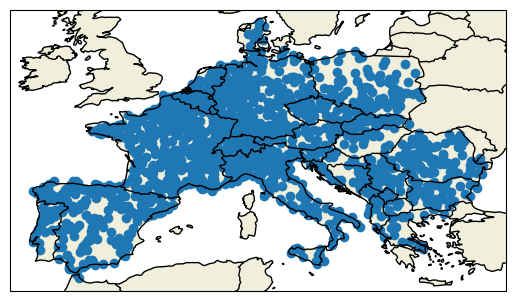

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, subplot_kw={'projection': ccrs.PlateCarree()})

ax.coastlines(resolution='50m')
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.BORDERS)

ax.scatter(unique_lons,unique_lats)

plt.show()

In [ ]:
len([id for id in dataset["ID"].unique()])

1494

In [ ]:
len(dataset.index)

39298176